# Probability Foundations — Part 3  
## Sampling Distributions and Limits

This notebook summarizes the main ideas from Chapter 4, **Sampling Distributions and Limits**, with emphasis on the conceptual structure that connects:

- sampling distributions,
- convergence in probability,
- almost-surely convergence,
- the weak and strong laws of large numbers,
- convergence in distribution,
- the central limit theorem,
- standard error and approximation error,
- Monte Carlo approximation,
- normal-distribution theory and the $\chi^2$, $t$, and $F$ distributions.

The purpose is not to reproduce the textbook line by line. Instead, the notebook organizes the chapter into one coherent learning narrative and preserves the main clarifications that emerged during the session.

## 1. Sampling distributions

Suppose

$$
X_1,\dots,X_n \overset{\text{i.i.d.}}{\sim} P
$$

and define a new random variable

$$
Y = h(X_1,\dots,X_n).
$$

The distribution of $Y$ is called a **sampling distribution** because $Y$ is constructed from a random sample.

Typical examples include

$$
\bar X = \frac{1}{n}\sum_{i=1}^n X_i,
\qquad
S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i-\bar X)^2,
$$

or more complicated functions such as maxima, geometric means, or nonlinear statistics.

The central problem is:

> Given the distribution of the original sample, what is the distribution of the statistic $Y$?

For small or simple problems, the sampling distribution can sometimes be derived exactly. For larger samples or more complicated statistics, exact calculation can become impractical. This motivates two approximation strategies developed later in the chapter:

1. **asymptotic approximation**, especially through the central limit theorem;
2. **Monte Carlo approximation**, where repeated simulation is used to estimate the distribution numerically.

### Why limiting distributions matter

Often there is a sequence of statistics

$$
Y_1,Y_2,\dots,Y_n,\dots
$$

where $Y_n$ depends on sample size $n$. Even if the exact distribution of $Y_n$ is complicated, its distribution may approach a much simpler limiting distribution.

This leads to the general strategy

$$
\text{complicated finite-}n\text{ distribution}
\quad \longrightarrow \quad
\text{simple limiting distribution}.
$$

The CLT is the most important example of this principle.

## 2. Convergence in probability

For deterministic sequences, convergence means that values get arbitrarily close to a limit. For random variables, the values themselves are random, so we need probabilistic notions of convergence.

A sequence $X_n$ **converges in probability** to $Y$ if, for every $\varepsilon>0$,

$$
\lim_{n\to\infty}
P\left(|X_n-Y|\ge \varepsilon\right)=0.
$$

Notation:

$$
X_n \xrightarrow{P} Y.
$$

Interpretation:

> For large $n$, the probability that $X_n$ differs from $Y$ by more than any fixed tolerance becomes arbitrarily small.

## 3. Weak Law of Large Numbers

Let

$$
M_n=\frac{X_1+\cdots+X_n}{n}
$$

be the sample mean. Under standard assumptions, the **Weak Law of Large Numbers (WLLN)** states

$$
M_n \xrightarrow{P} \mu,
\qquad
\mu=E[X_i].
$$

The result formalizes the intuitive statement that sample averages become reliable estimates of population means as sample size grows.

A useful proof pattern is:

$$
E[M_n]=\mu,
$$

and, using independence,

$$
\operatorname{Var}(M_n)
=
\operatorname{Var}\left(
\frac{1}{n}\sum_{i=1}^n X_i
\right)
=
\frac{1}{n^2}\sum_{i=1}^n\operatorname{Var}(X_i).
$$

If the variances are bounded by $v$,

$$
\operatorname{Var}(M_n)\le \frac{v}{n}.
$$

Then Chebyshev's inequality gives

$$
P(|M_n-\mu|\ge \varepsilon)
\le
\frac{\operatorname{Var}(M_n)}{\varepsilon^2}
\le
\frac{v}{n\varepsilon^2}
\to 0.
$$

So the shrinking variance of the sample mean is the core mechanism behind the weak law.

### Important variance rules

Two rules repeatedly matter in this chapter:

$$
\operatorname{Var}(aX)=a^2\operatorname{Var}(X),
$$

and, for independent $X_i$,

$$
\operatorname{Var}\left(\sum_i X_i\right)
=
\sum_i \operatorname{Var}(X_i).
$$

Therefore,

$$
\operatorname{Var}(M_n)
=
\frac{\sigma^2}{n}
$$

when the $X_i$ are i.i.d. with variance $\sigma^2$.

A key correction from the session was that the factor $n$ comes from **adding $n$ independent variances** before the outside $1/n^2$ factor is applied.

## 4. Almost-surely convergence

A sequence $X_n$ **converges almost surely** (or **with probability 1**) to $Y$ if

$$
P\left(\lim_{n\to\infty}X_n=Y\right)=1.
$$

Notation:

$$
X_n \xrightarrow{a.s.} Y.
$$

This is stronger than convergence in probability:

$$
X_n\xrightarrow{a.s.}Y
\quad\Longrightarrow\quad
X_n\xrightarrow{P}Y.
$$

The converse is not true in general.

## 5. Strong Law of Large Numbers

For i.i.d. random variables with finite mean $\mu$,

$$
M_n=\frac{1}{n}\sum_{i=1}^nX_i
$$

satisfies

$$
M_n\xrightarrow{a.s.}\mu.
$$

Equivalently,

$$
P\left(\lim_{n\to\infty}M_n=\mu\right)=1.
$$

The weak and strong laws therefore share the same limiting value, but differ in the **mode of convergence**:

$$
\text{WLLN: } M_n\xrightarrow{P}\mu,
$$

$$
\text{SLLN: } M_n\xrightarrow{a.s.}\mu.
$$

The strong law says that along almost every realized infinite sample path, the running average eventually settles near $\mu$ and stays near it.

## 6. Convergence in distribution

A sequence $X_n$ converges in distribution to $X$ if the distribution functions converge at continuity points of the limiting CDF:

$$
\lim_{n\to\infty}P(X_n\le x)=P(X\le x).
$$

Notation:

$$
X_n\xrightarrow{D}X.
$$

Intuitively:

> For large $n$, the entire distribution of $X_n$ looks increasingly like the distribution of $X$.

The implication hierarchy is

$$
\boxed{
X_n\xrightarrow{a.s.}X
\Longrightarrow
X_n\xrightarrow{P}X
\Longrightarrow
X_n\xrightarrow{D}X
}
$$

while the reverse implications are false in general.

## 7. Central Limit Theorem

Let $X_1,X_2,\dots$ be i.i.d. with finite mean $\mu$ and finite variance $\sigma^2$. Define

$$
S_n=X_1+\cdots+X_n,
\qquad
M_n=\frac{S_n}{n}.
$$

The standardized statistic is

$$
Z_n
=
\frac{S_n-n\mu}{\sqrt n\,\sigma}
=
\frac{M_n-\mu}{\sigma/\sqrt n}
=
\sqrt n\frac{M_n-\mu}{\sigma}.
$$

The **Central Limit Theorem** states

$$
Z_n\xrightarrow{D}N(0,1).
$$

Equivalently, for large $n$,

$$
M_n
\approx
N\left(\mu,\frac{\sigma^2}{n}\right).
$$

The original $X_i$ need not themselves be normally distributed.

### Why the factor $\sqrt n$ appears

The standardization rule itself has not changed.

For any random variable $Y$,

$$
Z=\frac{Y-E[Y]}{\operatorname{SD}(Y)}.
$$

For the sample mean,

$$
E[M_n]=\mu
$$

and

$$
\operatorname{Var}(M_n)=\frac{\sigma^2}{n},
$$

so

$$
\operatorname{SD}(M_n)=\frac{\sigma}{\sqrt n}.
$$

Therefore,

$$
Z_n
=
\frac{M_n-\mu}{\sigma/\sqrt n}.
$$

The $\sqrt n$ is not an arbitrary CLT correction. It appears because averaging $n$ independent observations shrinks the standard deviation of the mean by a factor $1/\sqrt n$.

Without this rescaling,

$$
M_n-\mu \to 0
$$

and its distribution collapses. Multiplying by $\sqrt n$ keeps the fluctuations on a non-degenerate scale.

## 8. LLN versus CLT

The LLN and CLT answer different questions.

### Law of Large Numbers

$$
M_n\to\mu
$$

describes **where the sample mean goes**.

### Central Limit Theorem

$$
\frac{M_n-\mu}{\sigma/\sqrt n}
\xrightarrow{D}N(0,1)
$$

describes **the shape and scale of the random error around $\mu$**.

A useful summary is:

$$
\text{LLN: consistency}
$$

$$
\text{CLT: asymptotic fluctuation}
$$

The LLN tells us that the error vanishes. The CLT tells us that the typical error is of order $1/\sqrt n$ and becomes approximately normal after standardization.

## 9. Understanding CLT simulation histograms

A major clarification from the session was the distinction between two different sample counts.

Suppose we want to visualize $Z_n$.

For one realization of $Z_n$, we generate

$$
X_1,\dots,X_n,
$$

compute their mean, and standardize it.

Then we repeat this entire experiment $N$ times:

$$
Z_n^{(1)},\dots,Z_n^{(N)}.
$$

The histogram is built from these $N$ values.

Therefore:

$$
\boxed{
n=\text{number of original observations combined into one }Z_n
}
$$

whereas

$$
\boxed{
N=\text{number of Monte Carlo repetitions used to visualize the distribution of }Z_n
}
$$

Increasing $n$ changes the sampling distribution and drives the CLT.

Increasing $N$ merely gives a more stable empirical picture of that distribution.

### Example: $Z_1$ versus $Z_2$

If the underlying distribution is uniform:

- $Z_1$ is based on one observation, so its distribution remains uniform;
- $Z_2$ is based on the standardized average of two observations, so its distribution changes shape;
- $Z_{10}$ can already look very close to normal.

Even if we generated one billion realizations of $Z_1$, the histogram would become a more accurate picture of the **uniform** distribution, not a normal distribution.

The CLT acts **within each $Z_n$** through averaging, not across the Monte Carlo repetitions used to draw the histogram.

## 10. Normal approximation and approximation quality

The CLT allows probabilities involving sums or means to be approximated by normal probabilities.

For example,

$$
P\left(
\frac{S_n-n\mu}{\sqrt n\,\sigma}
\le x
\right)
\approx
\Phi(x).
$$

For discrete distributions such as the binomial, a **continuity correction** can improve the approximation. For example,

$$
P(Y\le y)
$$

may be approximated using $y+0.5$ inside the corresponding normal calculation.

The required sample size for a good CLT approximation depends on the original distribution. There is no universal threshold such as $n=10$ or $n=30$. Tail behavior and skewness strongly influence the rate of convergence.

## 11. Standard error and estimating approximation error

Since

$$
\operatorname{Var}(M_n)=\frac{\sigma^2}{n},
$$

the standard deviation of the estimator $M_n$ is

$$
\frac{\sigma}{\sqrt n}.
$$

This quantity measures the typical sampling fluctuation of the sample mean and is called the **standard error** when viewed as the uncertainty of an estimator.

If $\sigma$ is unknown, estimate it with the sample standard deviation $S$:

$$
S^2
=
\frac{1}{n-1}
\sum_{i=1}^n(X_i-\bar X)^2.
$$

Then

$$
\widehat{\operatorname{SE}}(\bar X)
=
\frac{S}{\sqrt n}.
$$

A rough three-standard-error interval is

$$
\bar X
\pm
3\frac{S}{\sqrt n},
$$

which corresponds to a probability close to $0.9974$ under the normal approximation.

### Standard deviation versus standard error

These are related but different quantities.

- **Standard deviation** describes the spread of individual observations $X_i$.
- **Standard error** describes the spread of an estimator, such as $\bar X$, across repeated samples.

If

$$
\operatorname{SD}(X_i)=\sigma,
$$

then

$$
\operatorname{SE}(\bar X)
=
\frac{\sigma}{\sqrt n}.
$$

So the standard error becomes smaller as sample size increases even though the population standard deviation does not change.

## 12. Monte Carlo approximation

Monte Carlo methods use randomness to approximate quantities that may be deterministic and difficult to compute directly.

The central principle is the Law of Large Numbers:

$$
E[T]
\approx
\frac{1}{N}\sum_{i=1}^N T_i.
$$

The strategy is therefore:

1. rewrite the target quantity as an expectation;
2. simulate independent realizations of the corresponding random variable;
3. average them;
4. assess the Monte Carlo error using the standard error.

### Monte Carlo integration

Suppose

$$
I=\int_0^1 g(x)\,dx.
$$

If

$$
U\sim\operatorname{Uniform}(0,1),
$$

then

$$
I=E[g(U)].
$$

Therefore,

$$
I
\approx
\frac{1}{N}
\sum_{i=1}^N g(U_i).
$$

More generally, if $X$ has density $f$ on $(a,b)$,

$$
\int_a^b g(x)\,dx
=
E\left[\frac{g(X)}{f(X)}\right].
$$

Different choices of sampling density $f$ can lead to different estimator variances, so Monte Carlo algorithms can be compared by efficiency.

## 13. Approximating a sampling distribution by Monte Carlo

Suppose the statistic of interest is

$$
Y=h(X_1,\dots,X_n),
$$

where $X_1,\dots,X_n$ are sampled from some distribution $P$. Even if we know how to generate the $X_i$, the sampling distribution of $Y$ may be difficult to derive analytically. Monte Carlo gives us a direct way to approximate it.

To understand the construction, start from the CDF of $Y$:

$$
F_Y(y)=P(Y\le y).
$$

The key step is to rewrite this probability as an expectation. Define

$$
B=I(Y\le y)
=
\begin{cases}
1,&Y\le y,\\
0,&Y>y.
\end{cases}
$$

Because $B$ can only be $0$ or $1$, it is a Bernoulli random variable. Its success probability is exactly

$$
P(B=1)=P(Y\le y)=F_Y(y).
$$

Therefore,

$$
E[B]
=
1\cdot P(B=1)+0\cdot P(B=0)
=
F_Y(y),
$$

or equivalently,

$$
F_Y(y)=E[I(Y\le y)].
$$

This identity explains the whole Monte Carlo procedure. We are not assuming that the original statistic $Y$ is Bernoulli. Instead, for each fixed threshold $y$, we transform $Y$ into the Bernoulli indicator $I(Y\le y)$.

Now generate $N$ independent samples, each of size $n$:

$$
(X_{i1},X_{i2},\dots,X_{in}),
\qquad i=1,\dots,N.
$$

For each sample, calculate one realization of the statistic:

$$
Y_i=h(X_{i1},X_{i2},\dots,X_{in}).
$$

Then record whether that realization is at most $y$:

$$
B_i=I(Y_i\le y).
$$

The Monte Carlo estimate of the CDF is therefore

$$
\widehat F_Y(y)
=
\frac{1}{N}\sum_{i=1}^N B_i
=
\frac{1}{N}\sum_{i=1}^N I(Y_i\le y).
$$

So $\widehat F_Y(y)$ is simply the proportion of simulated values $Y_i$ that fall at or below $y$. Since the $B_i$ are i.i.d. Bernoulli with mean $F_Y(y)$, the law of large numbers gives

$$
\widehat F_Y(y)\to F_Y(y)
$$

as $N\to\infty$.

### Why the Bernoulli standard-error formula appears

The general Monte Carlo principle is

$$
E[g(Y)]
\approx
\frac{1}{N}\sum_{i=1}^N g(Y_i).
$$

CDF estimation is the special case

$$
g(Y)=I(Y\le y).
$$

Because this particular $g(Y)$ is Bernoulli, its variance is not an arbitrary variance:

$$
\operatorname{Var}(I(Y\le y))
=
F_Y(y)\bigl(1-F_Y(y)\bigr).
$$

Therefore the sampling variance of the Monte Carlo average is

$$
\operatorname{Var}(\widehat F_Y(y))
=
\frac{F_Y(y)(1-F_Y(y))}{N},
$$

and its standard error is

$$
\operatorname{SE}(\widehat F_Y(y))
=
\sqrt{\frac{F_Y(y)(1-F_Y(y))}{N}}.
$$

Since the true $F_Y(y)$ is exactly what we are trying to estimate, we substitute $\widehat F_Y(y)$:

$$
\widehat{\operatorname{SE}}
=
\sqrt{
\frac{
\widehat F_Y(y)\bigl(1-\widehat F_Y(y)\bigr)
}{N}
}.
$$

This is why the **Bernoulli form** of the error interval appears when approximating a CDF. The reason does not come from the distribution of $Y$ itself; it comes from the indicator variable used to express the CDF as an expectation.

The full chain is therefore

$$
(X_1,\dots,X_n)
\xrightarrow{h}
Y
\xrightarrow{I(\,\cdot\,\le y)}
B,
$$

where $B$ is Bernoulli and

$$
E[B]=F_Y(y).
$$

This also connects CDF estimation to the broader Monte Carlo framework. Different choices of $g$ produce different quantities:

- $g(Y)=I(Y\le y)$ estimates a CDF value or probability;
- a general $g(Y)$ estimates $E[g(Y)]$;
- an integral can often be rewritten as an expectation and estimated in exactly the same way.

One notation point is especially important here: $n$ is the size of each original sample used to construct one $Y_i$, while $N$ is the number of Monte Carlo repetitions used to approximate the distribution of $Y$.


## 14. Normal distribution theory

The normal distribution plays a central role because of both exact Gaussian identities and the CLT.

If

$$
X_i\sim N(\mu_i,\sigma_i^2)
$$

are independent, then for constants $a_i$ and $b$,

$$
\sum_i a_iX_i+b
\sim
N\left(
\sum_i a_i\mu_i+b,\,
\sum_i a_i^2\sigma_i^2
\right).
$$

In particular, if

$$
X_i\overset{iid}{\sim}N(\mu,\sigma^2),
$$

then

$$
\bar X
\sim
N\left(\mu,\frac{\sigma^2}{n}\right)
$$

**exactly for every $n$**.

This is stronger than the CLT, which gives an asymptotic approximation for general i.i.d. variables.

### Zero covariance and independence in the Gaussian setting

For suitable linear combinations $U$ and $V$ of the same independent normal variables,

$$
\operatorname{Cov}(U,V)=0
$$

if and only if $U$ and $V$ are independent.

This is a special Gaussian property.

In general,

$$
\operatorname{Cov}(X,Y)=0
$$

does **not** imply independence.

## 15. Chi-squared distribution

If

$$
Z_1,\dots,Z_k
\overset{iid}{\sim}
N(0,1),
$$

then

$$
Q
=
Z_1^2+\cdots+Z_k^2
\sim
\chi_k^2.
$$

The parameter $k$ is the **degrees of freedom**.

A key expectation is

$$
E[Q]=k.
$$

For a normal sample,

$$
\frac{(n-1)S^2}{\sigma^2}
\sim
\chi^2_{n-1}.
$$

This distribution is fundamental for inference about variance.

### Why the sample variance uses $n-1$

The usual sample variance is

$$
S^2
=
\frac{1}{n-1}
\sum_{i=1}^n(X_i-\bar X)^2.
$$

With this denominator,

$$
E[S^2]=\sigma^2.
$$

Thus $S^2$ is an unbiased estimator of the population variance.

The appearance of $n-1$ is also connected to the fact that estimating $\bar X$ uses up one degree of freedom.

## 16. The $t$ distribution

If

$$
Z\sim N(0,1),
\qquad
V\sim\chi_\nu^2,
$$

and $Z$ and $V$ are independent, then

$$
T
=
\frac{Z}{\sqrt{V/\nu}}
\sim
t_\nu.
$$

For a normal sample,

$$
\frac{\bar X-\mu}{S/\sqrt n}
\sim
t_{n-1}.
$$

The $t$-distribution looks similar to a standard normal distribution but has heavier tails because the denominator $S$ is itself random.

As the degrees of freedom increase,

$$
t_\nu
\xrightarrow{D}
N(0,1).
$$

## 17. $F$ distribution

If

$$
U\sim\chi_m^2,
\qquad
V\sim\chi_n^2,
$$

independently, then

$$
F
=
\frac{U/m}{V/n}
$$

has an $F$-distribution with $m$ and $n$ degrees of freedom.

The $F$-distribution is built from a ratio of independent variance-like quantities and later becomes important in variance comparison and related inference procedures.

## 18. Main conceptual connections

The chapter is easier to remember as one chain rather than a list of isolated theorems:

$$
\boxed{
\text{Sampling distribution}
\rightarrow
\text{convergence}
\rightarrow
\text{LLN}
\rightarrow
\text{CLT}
\rightarrow
\text{standard error}
\rightarrow
\text{Monte Carlo}
\rightarrow
\text{statistical inference}
}
$$

### LLN
Explains why averages are reliable.

### CLT
Explains the approximate distribution of their errors.

### Standard error
Quantifies the scale of those errors.

### Monte Carlo
Uses the LLN to approximate expectations and the CLT to assess simulation error.

### $\chi^2$, $t$, and $F$
Provide exact or near-exact distributions for common statistics in normal sampling and become building blocks for later inference.

## 19. Misconceptions corrected during the session

Several points were clarified through the discussion:

1. **The $\sqrt n$ in the CLT is not an arbitrary adjustment.**  
   It comes from
   $$
   \operatorname{SD}(M_n)=\sigma/\sqrt n.
   $$

2. **The histogram repetition count $N$ is not the CLT sample size $n$.**  
   $n$ determines the statistic being averaged; $N$ determines how accurately its distribution is visualized numerically.

3. **A huge number of realizations of $Z_1$ does not make $Z_1$ normal.**  
   It only produces a more accurate histogram of the true distribution of $Z_1$.

4. **The CDF value $F_Y(y)$ is not itself a Bernoulli random variable.**  
   The indicator
   $$
   I(Y\le y)
   $$
   is Bernoulli, and its expectation equals the CDF value.

5. **Monte Carlo CDF estimation is not $E[E[I]]$.**  
   The unknown population expectation
   $$
   E[I(Y\le y)]
   $$
   is estimated by the sample average of simulated indicators.

6. **The indicator function is just one possible choice of $g$.**  
   General Monte Carlo estimation uses
   $$
   E[g(Y)]
   \approx
   \frac1N\sum g(Y_i).
   $$

7. **Zero covariance does not imply independence in general.**  
   The equivalence holds only under special Gaussian conditions.

## 20. Minimal simulation: CLT intuition

The separate computer-exercises notebook will contain the more substantial implementation work. The short example below is included only to connect the theory to computation.

We compare standardized sample means from a uniform distribution for several values of $n$.

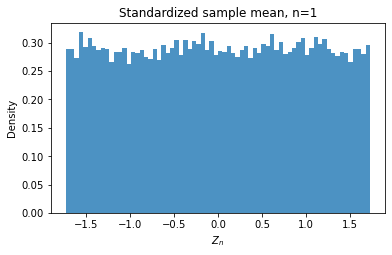

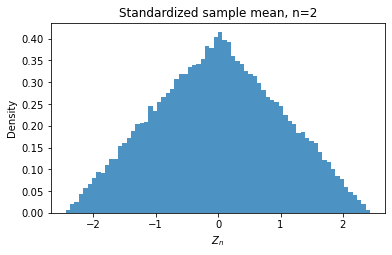

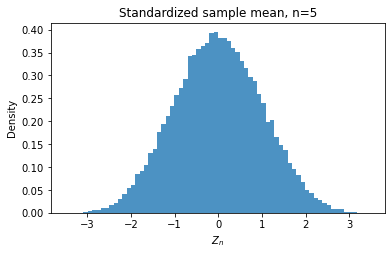

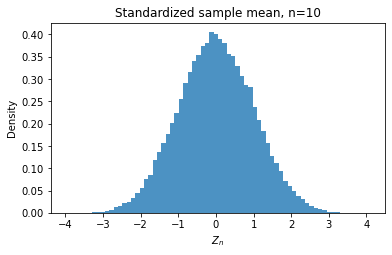

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

N = 50_000
sample_sizes = [1, 2, 5, 10]

mu = 0.5
sigma = np.sqrt(1/12)

for n in sample_sizes:
    x = rng.uniform(0, 1, size=(N, n))
    m = x.mean(axis=1)
    z = (m - mu) / (sigma / np.sqrt(n))

    plt.figure(figsize=(6, 3.5))
    plt.hist(z, bins=70, density=True, alpha=0.8)
    plt.title(f"Standardized sample mean, n={n}")
    plt.xlabel(r"$Z_n$")
    plt.ylabel("Density")
    plt.show()

Expected qualitative behavior:

- $n=1$: the standardized distribution is still uniform;
- small $n$: the histogram begins to round out;
- larger $n$: the standardized sample mean becomes increasingly close to $N(0,1)$.

The number $N$ controls how accurately the histogram reveals the distribution. The sample size $n$ controls the distribution itself.

## 21. Takeaways

The most important ideas from this chapter are:

$$
\boxed{
\bar X \text{ is itself a random variable with its own sampling distribution.}
}
$$

$$
\boxed{
\bar X\xrightarrow{P}\mu
\quad\text{and}\quad
\bar X\xrightarrow{a.s.}\mu
}
$$

under the corresponding laws of large numbers.

$$
\boxed{
\frac{\bar X-\mu}{\sigma/\sqrt n}
\xrightarrow{D}
N(0,1)
}
$$

by the central limit theorem.

$$
\boxed{
\operatorname{SE}(\bar X)
=
\frac{\sigma}{\sqrt n}
\approx
\frac{S}{\sqrt n}
}
$$

quantifies estimator uncertainty.

And Monte Carlo turns the LLN into a computational method:

$$
\boxed{
E[g(Y)]
\approx
\frac1N
\sum_{i=1}^N g(Y_i)
}
$$

which includes probability estimation, CDF estimation, integration, and sampling-distribution approximation as special cases.

## 22. Follow-up directions

Important statistical topics which may related to this chapter:

- estimators and their sampling distributions,
- bias and variance,
- consistency,
- maximum likelihood estimation,
- Bayesian inference,
- confidence intervals and hypothesis testing,
- the role of $\chi^2$, $t$, and $F$ distributions in classical inference.

A separate notebook will be used for the chapter's computer exercises and simulation-based demonstrations.